In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plots import *

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lesukhin_AV\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv('yelp.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22163 entries, 0 to 22162
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    22163 non-null  str  
 1   label   22163 non-null  int64
dtypes: int64(1), str(1)
memory usage: 346.4 KB


In [4]:
df.head(5)

,text,label
0,i will continue to recommend prime roofing to ...,1
1,delivery was pretty quick & they 're open late .,1
2,that 's the nicest word i can use to sum up ou...,0
3,corona bottle ) stuck in it .,0
4,took another _num_ mins to get our orders taken .,0


In [5]:
df.duplicated().sum()

np.int64(1448)

In [3]:
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

text     0
label    0
dtype: int64

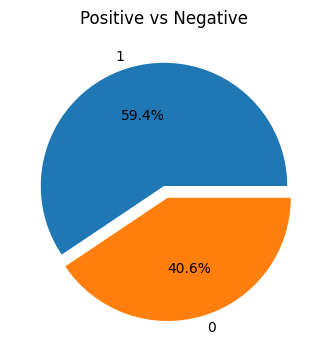

In [8]:
#Посмотрим на распределение классов. Для оценки качества можем использовать обычную точность (accuracy), так как классы достаточно сбалансированы.
df['label'].value_counts().plot(kind='pie', explode=[0, 0.1], figsize=(4, 4), autopct='%1.1f%%')
plt.title("Positive vs Negative")
plt.show()

In [6]:
# Посмотрим на распределение количества символов в тексатх

In [9]:
df['text_char_length'] = df['text'].str.len()

<Axes: xlabel='text_char_length', ylabel='Count'>

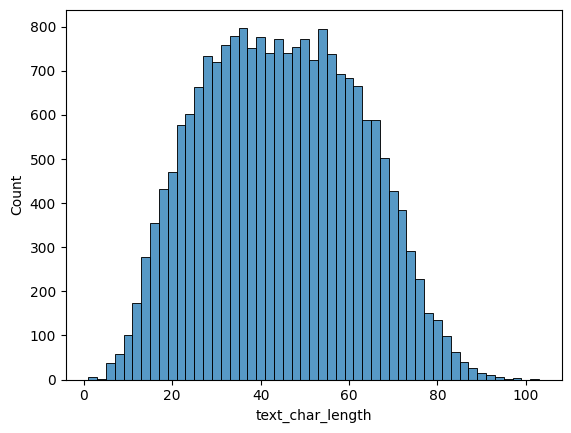

In [10]:
sns.histplot(df['text_char_length'])

In [7]:
# Посмотрим на распределение количества слов в тексатх

In [11]:
df['text_word_length'] = df['text'].apply(lambda x: len(x.split()))

<Axes: xlabel='text_word_length', ylabel='Count'>

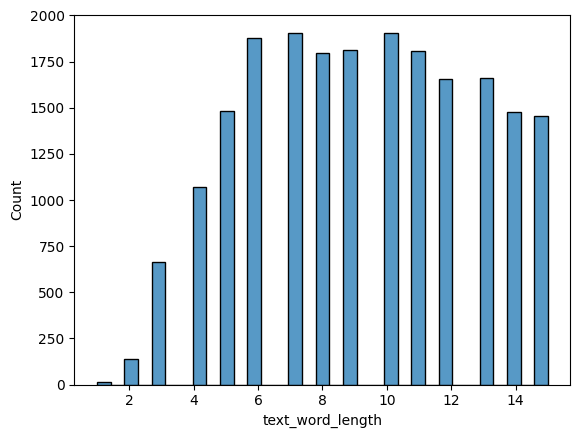

In [12]:
sns.histplot(df['text_word_length'])

In [8]:
# Посмотрим на ТОП 50 саых частых слов в текстах

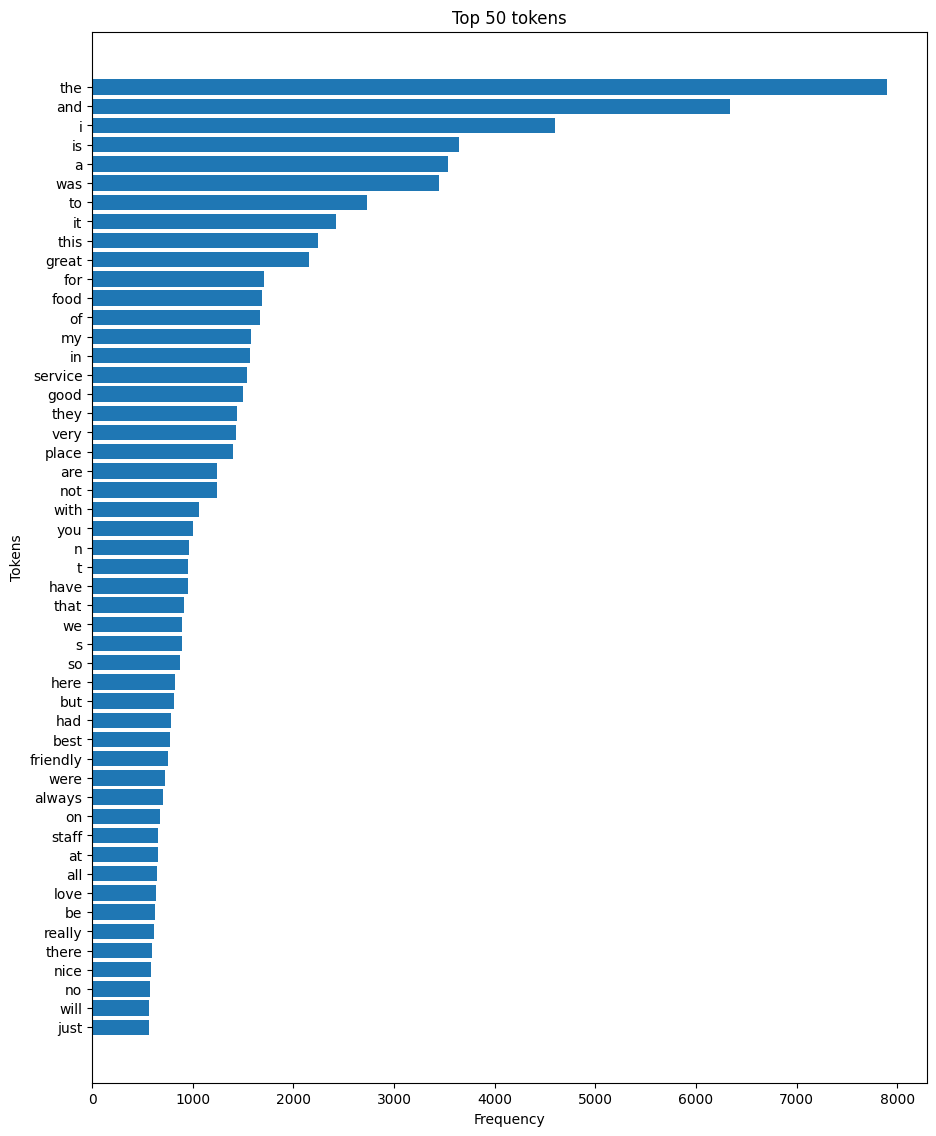

In [4]:
plot_top_tokens(df, top_n=50, remove_stopwords=False)

In [9]:
# Посмотрим на ТОП 50 саых частых слов в текстах (без стоп-слов)

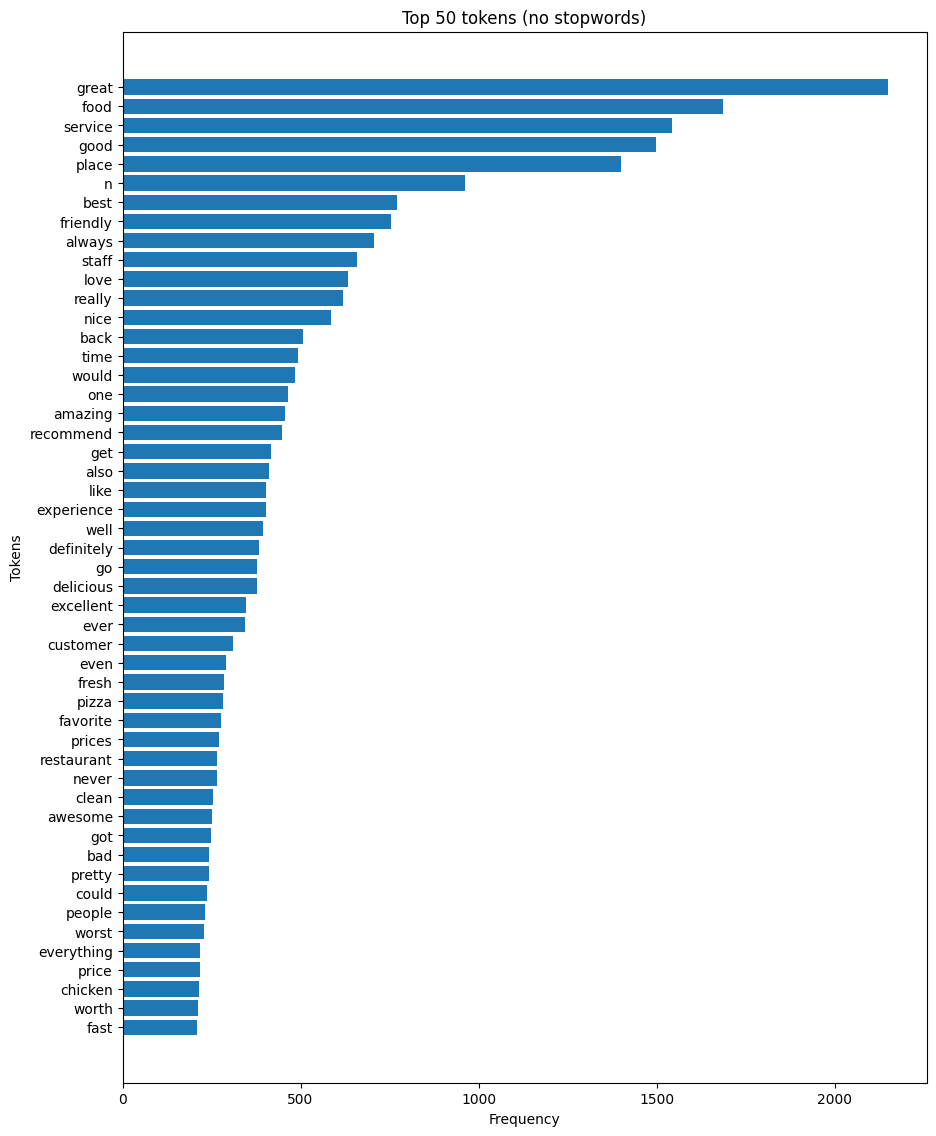

In [5]:
plot_top_tokens(df, top_n=50, remove_stopwords=True)

In [4]:
# Посмотрим на важность токенов для классификации с помощью ANOVA F-test с удалением стоп-слов

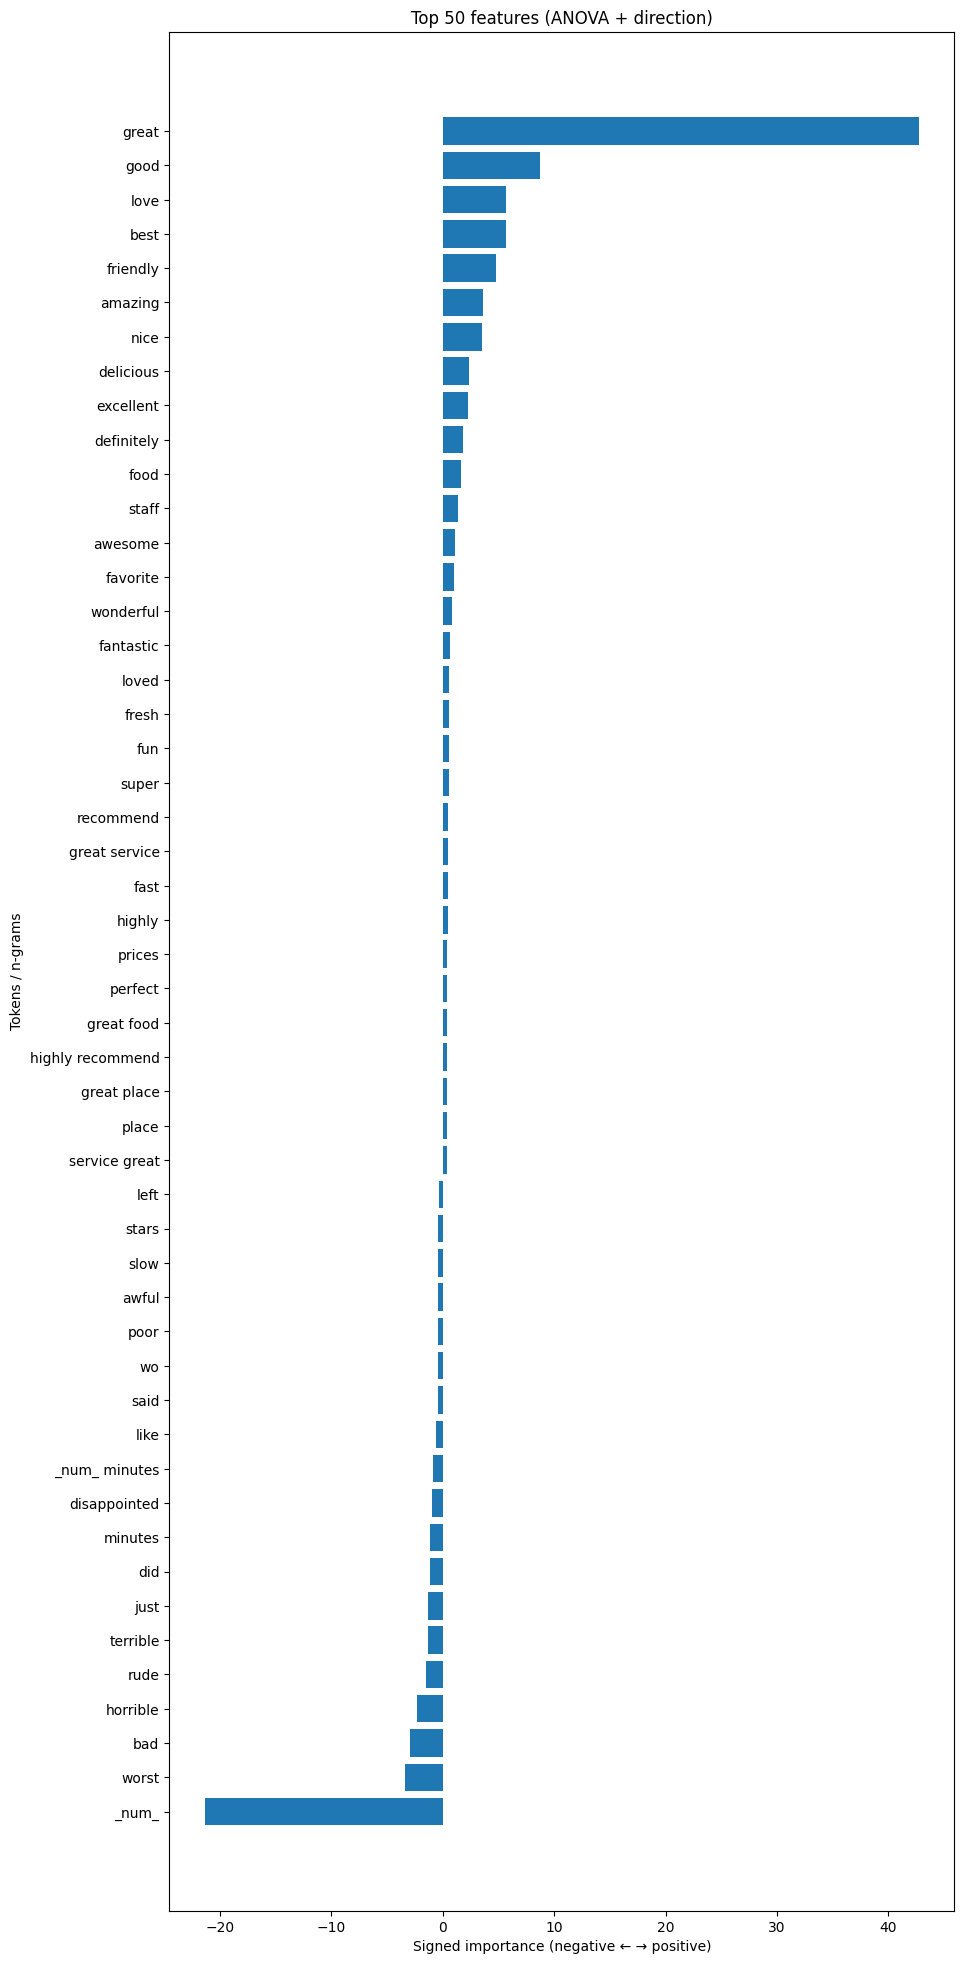

In [6]:
plot_top_features_anova_signed(df, top_n=50, remove_stopwords=True)

In [8]:
# Посмотрим на важность токенов для классификации с помощью ANOVA F-test БЕЗ удалением стоп-слов

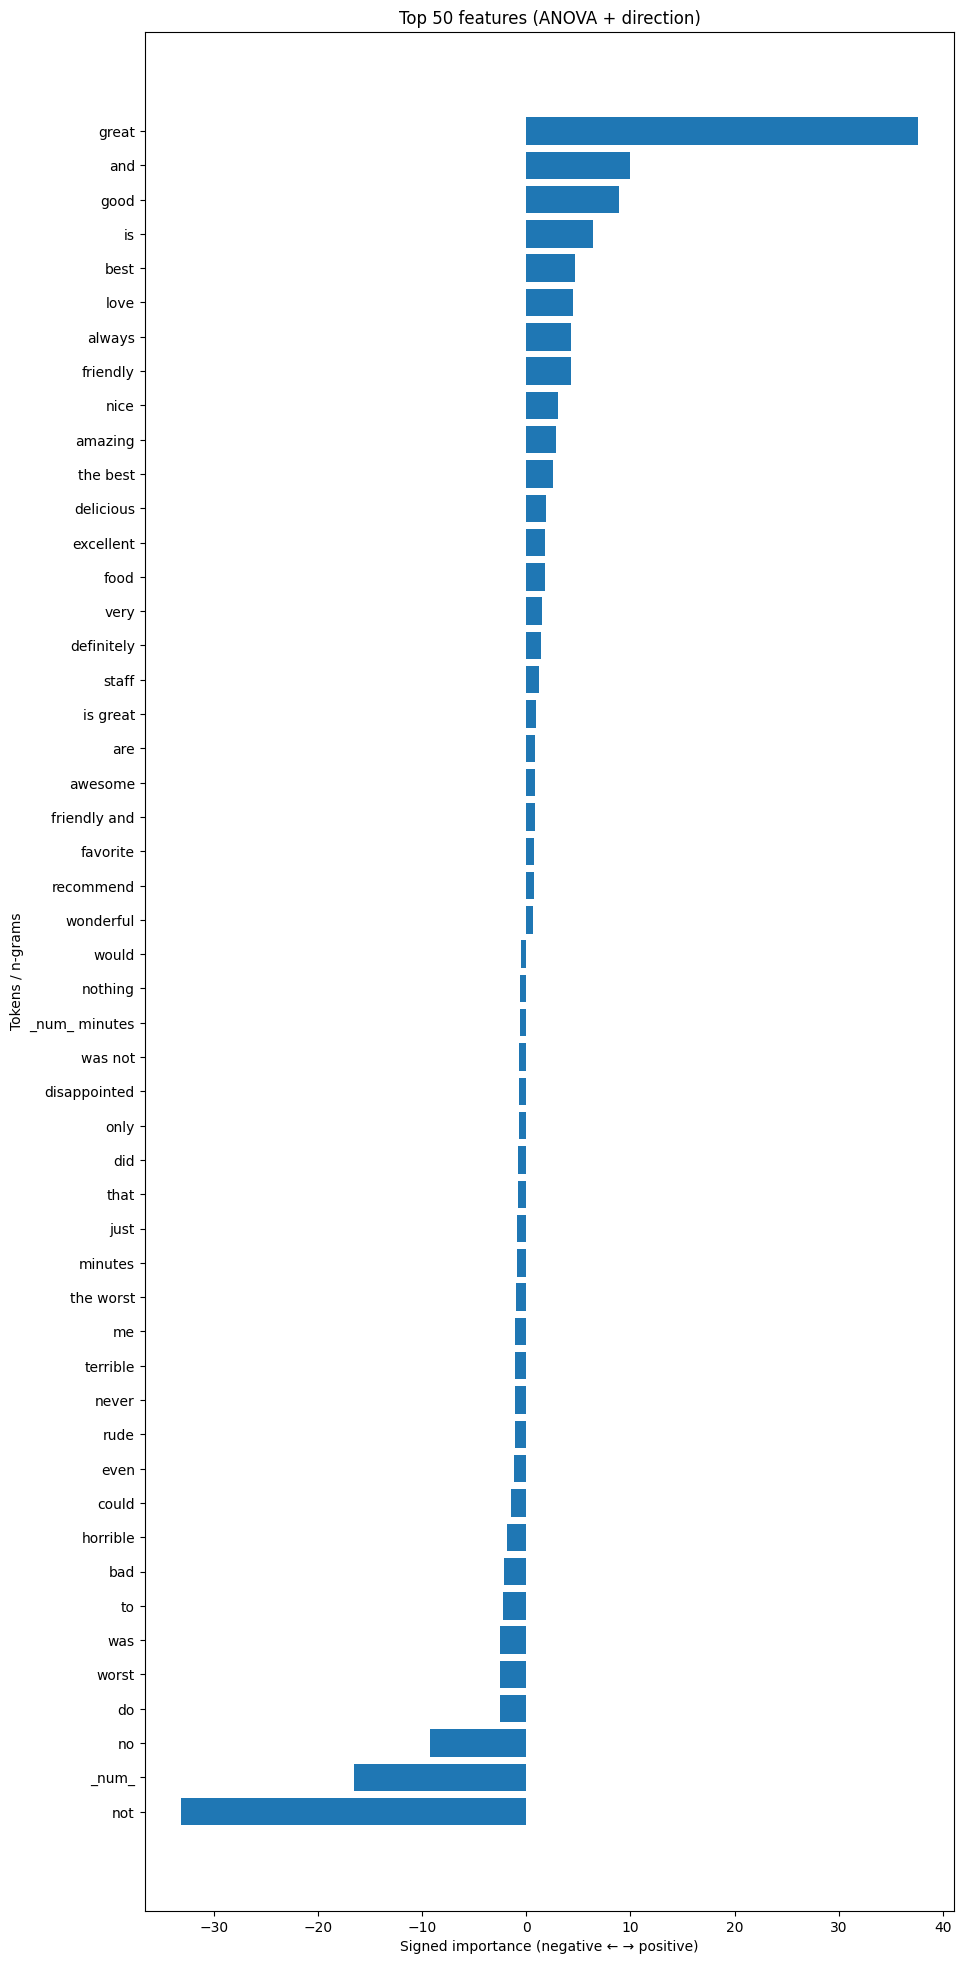

In [7]:
plot_top_features_anova_signed(df, top_n=50, remove_stopwords=False)

## Видно, что стоп-слова например такие как no, not являются потенциально хорошими предикатами для будущих моделей. Их удаление модет ухудшить результаты.  